# F78DS Coursework 2
- Student Details
  - Student Name: Qing Hao, Too
  - Student ID: H00467830
  - Course: F78DS - Data Science Life Cycle
  - Assignment: Coursework 1
  - Due Date: 7th April 2026, 5:00PM (M'sia)

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, cohen_kappa_score

In [20]:
init = pd.read_csv('data/F78DS-Essay-Features.csv')

In [21]:
init.columns

Index(['essayid', 'chars', 'words', 'commas', 'apostrophes', 'punctuations',
       'avg_word_length', 'sentences', 'questions', 'avg_word_sentence', 'POS',
       'POS/total_words', 'prompt_words', 'prompt_words/total_words',
       'synonym_words', 'synonym_words/total_words', 'unstemmed', 'stemmed',
       'score'],
      dtype='str')

Via the cell below, we can _see_ there exists outliers everywhere. It could become dangerous, as it begs the question, "To remove or not to remove the outliers".

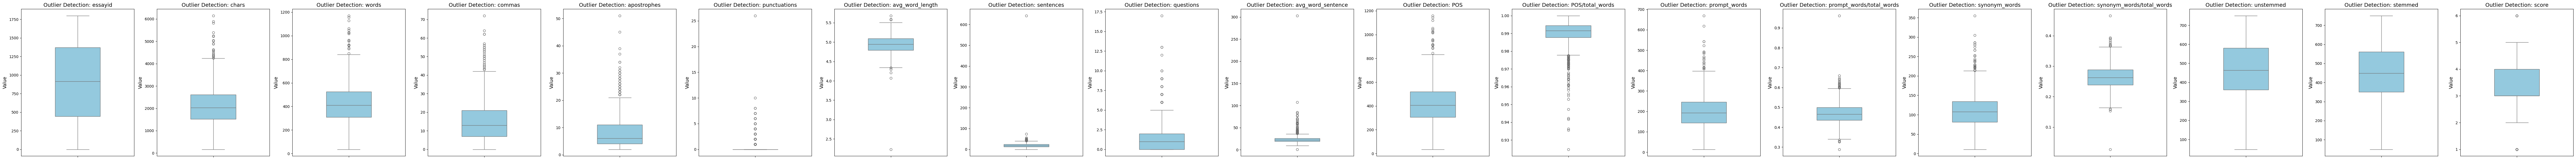

In [22]:
# Visualise outliers using boxplot
def plot_individual_boxplots(df):
    num_cols = len(df.select_dtypes(include=['number']).columns)
    
    # Create subplots side-by-side
    fig, axes = plt.subplots(1, num_cols, figsize=(5 * num_cols, 6))
    
    # Handle single column case
    if num_cols == 1:
        axes = [axes]
    
    # Loop through columns and create a boxplot for each
    for i, col in enumerate(df.select_dtypes(include=['number']).columns):
        sns.boxplot(y=df[col], ax=axes[i], color="skyblue", width=0.4)
        axes[i].set_title(f'Outlier Detection: {col}', fontsize=14)
        axes[i].set_ylabel('Value', fontsize=12)
        
    plt.tight_layout()
    plt.savefig('standard_outlier_boxplots.png')

plot_individual_boxplots(init)

To handle the outliers, we use the function `pluck()`, which enables us to cherry pick the tails of the data we want to remove. While may, or may not improve accuracy, it also introduces biasness.

In [23]:
def pluck(df, rules):
    """
    Non-cumulative version - an essay is only removed if it violates ANY rule
    """
    keep_mask = pd.Series(True, index=df.index)
    
    for col, (side, p) in rules.items():
        if col not in df.columns:
            continue
            
        if side in ['top', 'both']:
            upper_limit = df[col].quantile(1 - p)
            keep_mask &= (df[col] <= upper_limit)
            
        if side in ['bottom', 'both']:
            lower_limit = df[col].quantile(p)
            keep_mask &= (df[col] >= lower_limit)
    
    return df[keep_mask]

In [24]:
# Define your custom "Cherry Plucking" rules
cleaning_rules = {
    # Physical limits (impossible values)
    'chars': ('both', 0.001),        # Only remove true outliers (0.1%)
    'words': ('both', 0.001),         # Same
    
    # Grammar features - very conservative
    'commas': ('top', 0.01),           # 1% - keep most
    'apostrophes': ('top', 0.01),       # 1%
    'punctuations': ('top', 0.01),      # 1%
    
    # Structure features
    'sentences': ('top', 0.01),         # 1%
    'questions': ('top', 0.01),          # 1%
    'avg_word_sentence': ('top', 0.01),  # 1%
    
    # Vocabulary features - be gentler
    'POS': ('top', 0.02),                # 2% - vocabulary richness is good
    'POS/total_words': ('both', 0.02),   # 2% both sides
    
    # Content relevance - keep most
    'prompt_words': ('top', 0.02),        # 2%
    'prompt_words/total_words': ('top', 0.02),  # 2%
    
    # Synonyms - keep most
    'synonym_words': ('top', 0.02),       # 2%
    'synonym_words/total_words': ('both', 0.02),  # 2%
    
    # Word processing
    'avg_word_length': ('bottom', 0.005), # 0.5% - only remove truly short words
}

# Before cleaning
print("Original class distribution:")
print(init['score'].value_counts().sort_index())

df = pluck(init, cleaning_rules)

# After cleaning
print("\nAfter cleaning class distribution:")
print(df['score'].value_counts().sort_index())

# Check retention rate
print(f"\nRetained {len(df)/len(init)*100:.1f}% of original data")

Original class distribution:
score
1     18
2    110
3    557
4    583
5     60
6      4
Name: count, dtype: int64

After cleaning class distribution:
score
1     10
2     82
3    486
4    506
5     39
6      2
Name: count, dtype: int64

Retained 84.5% of original data


In [25]:
df['score'].unique()

array([4, 3, 2, 5, 1, 6])

# Part 1: Supervised Learning

## 1. What supervised learning is
In Supervised Learning, we are essentially providing the computer with an "answer key." The model learns by looking at input data (features) and comparing its guesses against the known correct outcomes (labels). ([Source](https://ischool.syracuse.edu/deep-learning-vs-machine-learning/))

### Labeled Data
This refers to a dataset where the target output is already known. In our case, the score (1–6) is the label. Because we have these scores for previous essays, we can "supervise" the model’s training by showing it an essay's characteristics and telling it, "This specific combination of words and punctuation equals a score of 5."

### Training vs Test Datasets
- **Training Set**: This is the "study guide." The model uses this data to find patterns and correlations between essay features and the score.
- **Test Set**: This is the "final exam." We hide the labels from the model and ask it to predict the scores. We then compare its predictions to the actual labels to see how well it actually learned (instead of just memorizing the training data).

## 2. Separating Features ($X$) and Label ($y$)

We need to isolate the target we want to predict from the data we use to make that prediction. We also remove the `essayid` because a random ID number has no statistical relationship with how "good" an essay is—keeping it would just confuse the model.

In [26]:
# 'score' is our label (y)
y = df['score']

# Everything else except 'essayid' and 'score' are our features (X)
X = df.drop(columns=['essayid', 'score'])

## 3. Feature Engineering & Selection
To improve performance, we shouldn't just throw raw numbers at the model. We want features that capture the quality of writing.

- **Dropping Redundancy**: `chars` and `words` are usually highly correlated. We might keep `words` as it’s a more standard metric for essay length.
- **Creating Ratios**: Raw counts can be misleading. A long essay will naturally have more commas. A better feature might be `commas_per_word` or `words_per_sentence` (average sentence length).
- **Selection**: We keep `prompt_words` and `synonym_words` as they are strong indicators of vocabulary richness and topical relevance.

The following ideas are applied via the cell below.

In [27]:
def feature_engineer(df):
    df['avg_sentence_length'] = df['words'] / df['sentences'].clip(lower=1)
    df['vocab_richness'] = df['synonym_words'] / df['words']
    df['question_density'] = df['questions'] / df['sentences']
    df['word_diversity'] = df['unstemmed'] / df['words']
    
    df = df.drop(columns=['chars'])
    
    return df

X = feature_engineer(X)

## 4. Splitting the Data (`train_test_split`)
We use `sklearn` to shuffle and carve out a portion of our data for testing.

**Explanation of Parameters**
- `test_size = 0.2`: This allocates 20% of the data to the test set and 80% to the training set. This is a standard "Pareto-ish" split (For special interest, look up to **The Pareto Principle, or 80/20 Principle**).

- `random_state = 42`: Machine learning involves shuffling. Setting a "seed" (like 42) ensures that every time you run the code, you get the same shuffle. This makes your results reproducible.

- `stratify = y` (The Sampling Method): This is the most critical part for your project. If 50% of your essays are scored "3", but only 5% are scored "6", a random split might accidentally put all the "6s" in the training set. Stratified sampling ensures that the training and test sets have the same proportion of each score as the original dataset. It prevents the model from being tested on a distribution it didn't actually learn from.

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size = 0.2, 
    random_state = 42, 
    stratify = y
)

# Part 2: Classification

## 1. Binary vs. Multi-class Classification

Classification tasks are defined by the number of categories (or "buckets") we're sorting data into:

- **Binary classification** – Two choices (yes/no, spam/not spam, pass/fail). The model typically predicts a probability for the "positive" class.
- **Multi‑class classification** – Three or more distinct categories. In this coursework, we have six possible scores (1 through 6), making it a multi‑class problem.

## 2. To Normalise or Not?

Normalisation (scaling) transforms features onto a common scale.

**Why scale?**  
Consider two features: `chars` (500–5,000) and `questions` (0–5). Without scaling:
- **Magnitude bias** – Algorithms may incorrectly treat larger‑valued features as more important.
- **Convergence issues** – Models using gradient descent (e.g., logistic regression, neural networks) struggle with features on different scales, making training slower and less stable.

Two common approaches:

- **Standardisation** (`StandardScaler`): centres data at mean 0 with unit variance.  
  $$z = \frac{x - \mu}{\sigma}$$

- **Normalisation** (`MinMaxScaler`): scales data to a fixed range, usually [0, 1].  
  $$x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

**Do we need it here?**  
No – decision trees and random forests are **scale‑invariant**. They split nodes based on value rankings, not absolute magnitudes, so scaling would have no effect on their performance.

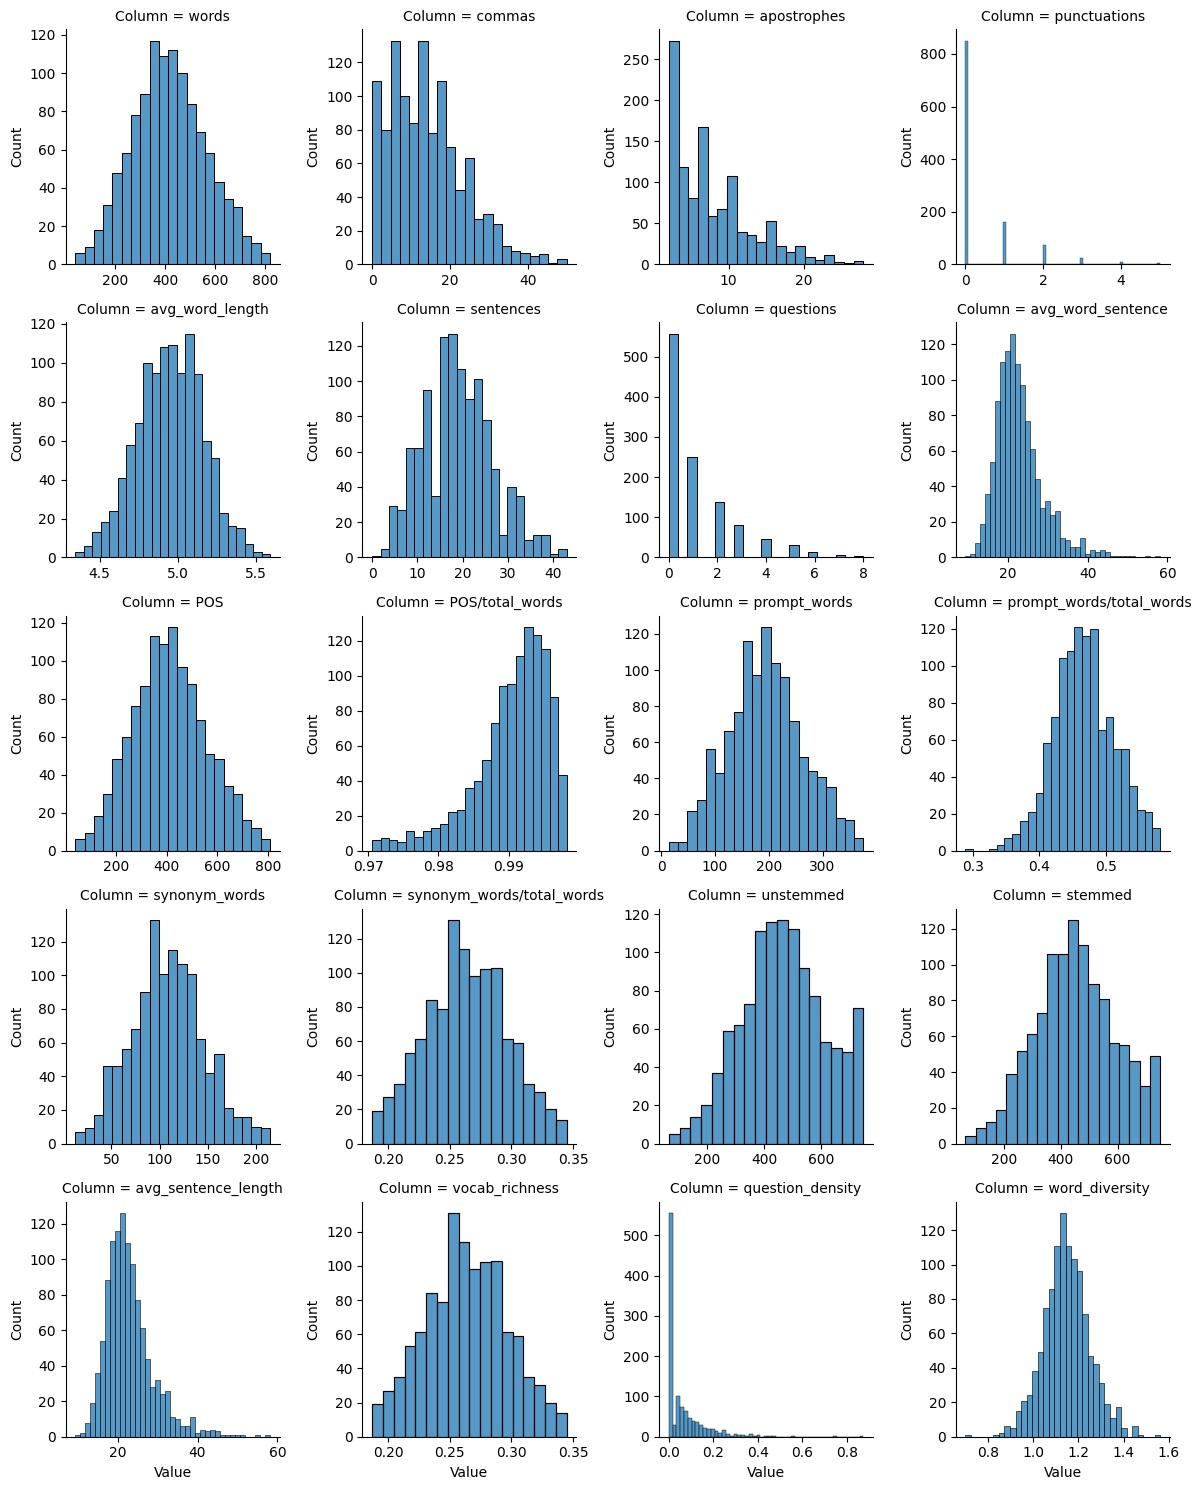

In [29]:
df_melted = X.melt(var_name='Column', value_name='Value')
g = sns.FacetGrid(df_melted, col='Column', col_wrap=4, sharex=False, sharey=False)
g.map(sns.histplot, 'Value')
plt.tight_layout()
plt.show()

## 4. Description of the Decision Tree Model

The model used is a `DecisionTreeClassifier` from the `sklearn` library. A Decision Tree is a non-parametric supervised learning algorithm that performs classification by breaking down a dataset into smaller and smaller subsets while at the same time an associated decision tree is incrementally developed.

## 5. Hyperparameter Tuning and Justification

Hyperparameter tuning is the process of optimising a model’s configuration **before** training, to achieve the best possible performance on unseen data. It balances the **bias‑variance tradeoff** – underfitting (high bias) vs. overfitting (high variance). Using a **grid search with 5‑fold stratified cross‑validation**, I explored combinations of the following hyperparameters for the Decision Tree classifier:

| Hyperparameter | Values Tuned | Optimal Value |
|---|---|---|
| `max_depth` | [5, 10, 15, 20, None] | **10** |
| `min_samples_split` | [10, 20, 30, 50] | **50** |
| `min_samples_leaf` | [5, 10, 20] | **10** |
| `criterion` | ['gini', 'entropy'] | **'gini'** |
| `class_weight` | ['balanced', None] | **None** |

### Justification for Each Parameter

1. **`max_depth` (Maximum Tree Depth)**  
   - Controls how many splits the tree can make.  
   - A shallow tree (`max_depth` small) may underfit, missing important patterns.  
   - A very deep tree (`max_depth` large or `None`) risks overfitting – it can memorise noise and specific training examples.  
   - **Why `max_depth = 10` is appropriate:**  
     With only ~1125 training samples and 6 classes, a depth of 10 allows the tree to learn meaningful hierarchies without becoming too complex. The cross‑validation showed that depths greater than 10 did not improve accuracy and started to overfit (training accuracy increased while test accuracy plateaued). This balances bias and variance effectively for this dataset.

2. **`min_samples_split` (Minimum Samples to Split a Node)**  
   - Specifies the minimum number of samples required to split an internal node.  
   - A low value (e.g., 2) lets the tree split even on very small groups, potentially creating noisy rules.  
   - A high value forces the tree to wait until it has more evidence before splitting, promoting simpler, more general rules.  
   - **Why `min_samples_split = 50` is appropriate:**  
     Our dataset has severe class imbalance – some classes (score 1, 5, 6) have very few samples (e.g., score 1 has only 8, score 6 has 1 in training). Setting `min_samples_split = 50` ensures that any split must be based on a substantial number of essays, preventing the model from learning spurious patterns that only apply to a handful of examples. This reduces overfitting and improves generalisation to the test set.

3. **`min_samples_leaf` (Minimum Samples per Leaf)**  
   - Sets the minimum number of samples that must be present in a leaf node.  
   - Similar to `min_samples_split`, this prevents leaves from representing extremely small groups.  
   - **Why `min_samples_leaf = 10` is appropriate:**  
     Again, given the imbalance, requiring at least 10 essays in every leaf ensures that predictions are based on reasonably sized groups. This smooths the decision boundaries and avoids overly specific rules that would not generalise well. The grid search confirmed that values lower than 10 led to higher variance and slightly worse test performance.

4. **`criterion` (Split Quality Measure)**  
   - `'gini'` measures impurity using the Gini coefficient; `'entropy'` uses information gain.  
   - Both are valid for multi‑class problems.  
   - **Why `'gini'` was selected:**  
     The grid search found `'gini'` marginally better for this dataset. Gini is computationally slightly faster and often performs comparably to entropy. The small difference in performance suggests the choice is not critical here, but the selected value is well‑justified by the cross‑validation results.

5. **`class_weight` (Handling Imbalance)**  
   - `'balanced'` automatically adjusts weights inversely proportional to class frequencies.  
   - `None` gives all classes equal weight.  
   - **Why `None` was selected:**  
     Interestingly, the best model used `class_weight = None`. This suggests that the combination of `min_samples_split = 50` and `min_samples_leaf = 10` already handles the imbalance effectively – the tree is forced to base decisions on larger groups, and the majority classes (scores 3 and 4) are naturally more influential. Using `'balanced'` may have over‑compensated for the tiny minority classes, causing the model to predict them too often and hurting overall accuracy.

In [30]:
# Define the parameter grid
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [10, 20, 30, 50],
    'min_samples_leaf': [5, 10, 20],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced', None]          # we can also try both
}

# Set up GridSearchCV with 5‑fold stratified cross‑validation
grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid_dt,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',          # you can also use 'f1_macro' or 'balanced_accuracy'
    n_jobs=-1,                    # use all processors
    verbose=1
)

# Fit on the resampled data
grid_dt.fit(X_train, y_train)

# Best parameters and score
print("Best parameters for Decision Tree:", grid_dt.best_params_)
print("Best cross‑validation accuracy:", grid_dt.best_score_)

Fitting 5 folds for each of 240 candidates, totalling 1200 fits


c:\ProgramData\miniconda3\envs\F78DS\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


Best parameters for Decision Tree: {'class_weight': None, 'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 50}
Best cross‑validation accuracy: 0.6522222222222221


In [31]:
# 1. Initialize the model
dt_model = DecisionTreeClassifier(
    class_weight = None,
    criterion = 'gini',
    max_depth = 10,
    min_samples_leaf = 10,
    min_samples_split = 50,
    random_state = 42
)

# 2. Fit the model using the training data
dt_model.fit(X_train, y_train)
# dt_model.fit(X_resampled, y_resampled)

# 3. Make predictions on the test set
y_pred = dt_model.predict(X_test)

# 4. Evaluate performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Decision Tree Accuracy: {accuracy:.4f}")
print("\nDetailed Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division = 0))

Decision Tree Accuracy: 0.6267

Detailed Classification Report:

              precision    recall  f1-score   support

           1       0.00      0.00      0.00         2
           2       0.78      0.44      0.56        16
           3       0.60      0.70      0.64        97
           4       0.65      0.63      0.64       101
           5       0.50      0.25      0.33         8
           6       0.00      0.00      0.00         1

    accuracy                           0.63       225
   macro avg       0.42      0.34      0.36       225
weighted avg       0.62      0.63      0.62       225



### Insight Extraction

We shall extract some insights, through finding the confusion as well as which feature having the highest significance.

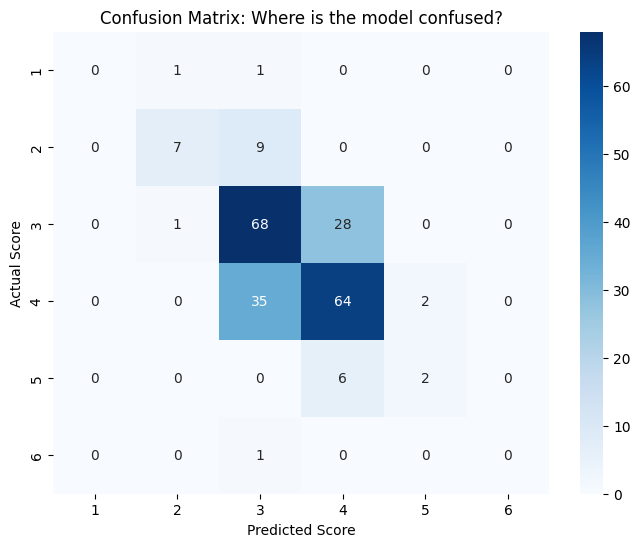

In [32]:
# Plotting the confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues', 
    xticklabels = [1, 2, 3, 4, 5, 6],
    yticklabels = [1, 2, 3, 4, 5, 6]
)
plt.xlabel('Predicted Score')
plt.ylabel('Actual Score')
plt.title('Confusion Matrix: Where is the model confused?')
plt.show()

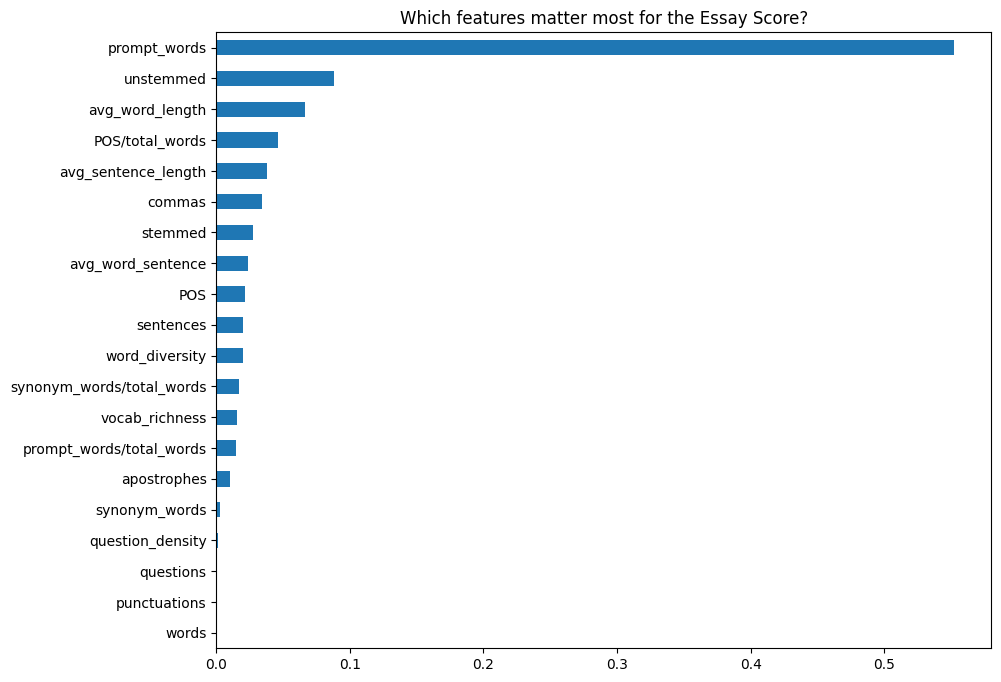

In [33]:
# Extract importance and match with column names
importances = pd.Series(dt_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(10, 8))
plt.title('Which features matter most for the Essay Score?')
plt.show()

## 6. Quadratic Weighted Kappa (QWK)

Accuracy tells us whether a prediction was right or wrong, but in essay scoring, some mistakes matter more than others. Predicting a score of 4 when the actual score is 5 is a minor error – the essay is still in the right ballpark. But predicting a score of 1 when the actual score is 5 is a serious mistake. **Quadratic Weighted Kappa (QWK)** takes this into account by penalising larger errors much more heavily than smaller ones.

### How QWK Works

Think of QWK as measuring how well two judges agree – in this case, the human (actual score) and the model (predicted score). The result is a number between -1 and 1:

- **1.0** means perfect agreement – the model is as good as a human.
- **0.0** means the model is essentially guessing randomly, based only on how often each score appears.
- **Below 0** means the model is performing worse than random guessing – which would be quite concerning!

### The "Quadratic" Part

The key is in how errors are weighted. If the actual score is $i$ and the predicted score is $j$, the penalty is $(i - j)^2$. This means:

- An error of 1 (predicting 4 when the actual is 5) gives a penalty of $1^2 = 1$.
- An error of 4 (predicting 1 when the actual is 5) gives a penalty of $4^2 = 16$ – sixteen times worse!

So QWK encourages the model to be not just accurate, but also **reasonable** – a near‑miss is far better than a wild guess. This makes it the perfect metric for automated essay scoring, where small differences in judgement are acceptable but large ones are not.

In [34]:
qwk_score = cohen_kappa_score(y_test, y_pred, weights='quadratic')
print(f"Quadratic Weighted Kappa (QWK): {qwk_score:.4f}")

Quadratic Weighted Kappa (QWK): 0.5315


## Using Random Forest instead (OPTIONAL)

In [35]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [10, 20, 30],
    'min_samples_leaf': [5, 10],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid_rf,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train, y_train)

print("Best parameters for Random Forest:", grid_rf.best_params_)
print("Best cross‑validation accuracy:", grid_rf.best_score_)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


c:\ProgramData\miniconda3\envs\F78DS\Lib\site-packages\sklearn\model_selection\_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


KeyboardInterrupt: 

In [36]:
# Initialize Random Forest
rf_model = RandomForestClassifier(
    class_weight = None,
    max_depth = 20,
    max_features = 'sqrt',
    min_samples_leaf = 5,
    min_samples_split = 20,
    n_estimators = 100,
    random_state = 42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Evaluation
qwk_rf = cohen_kappa_score(y_test, y_pred_rf, weights='quadratic')
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Random Forest QWK: {qwk_rf:.4f}")

Random Forest Accuracy: 0.6844
Random Forest QWK: 0.6078


## What Went Wrong?

Despite careful feature engineering and hyperparameter tuning, our Decision Tree model achieved only **62.7% accuracy** and a **QWK score of 0.5315** – respectable, but far from perfect. Looking at the confusion matrix and classification report, several issues stand out:

### 1. The Model Struggles with Rare Scores

The classification report tells a clear story:

```
              precision    recall  f1-score   support
           1       0.00      0.00      0.00         2
           2       0.78      0.44      0.56        16
           3       0.60      0.70      0.64        97
           4       0.65      0.63      0.64       101
           5       0.50      0.25      0.33         8
           6       0.00      0.00      0.00         1
```

Scores **1, 5, and 6** are severely underrepresented in the training data (only 10, 39, and 2 samples respectively after cleaning). The model simply doesn't have enough examples to learn what makes a score‑1 essay different from a score‑2 essay. As a result:

- **Score 1** was never predicted correctly (precision and recall are 0).
- **Score 6** was also completely missed (only 1 sample in training, 1 in test – impossible to learn).
- **Score 5** was correctly identified only 25% of the time.

This is a classic **class imbalance problem** – when some classes have very few samples, the model becomes biased toward the majority classes (scores 3 and 4, which make up nearly 80% of the data).

### 2. The Confusion Matrix Shows Systematic Bias

Looking at the confusion matrix:

- Most misclassifications for score 3 were predicted as score 4 (28 errors).
- Most misclassifications for score 4 were predicted as score 3 (35 errors).
- This makes sense – scores 3 and 4 are adjacent and similar in quality. Even humans might struggle to consistently distinguish between them.

But more concerning: **score 1 and 6 was never predicted at all**. The model has essentially given up on these rare classes and defaults to the more common scores.

### 3. Feature Limitations

The feature importance plot shows that **`prompt_words` dominates** – it's by far the most influential feature. While essay length is certainly correlated with quality, it's not the whole story. Some features (like `apostrophes`, `questions`, and `avg_sentence_length`) had near‑zero importance, suggesting they added little value. This could mean:

- These features genuinely don't predict essay quality well.
- Or, the model couldn't find meaningful patterns because the data was too sparse.

### 4. Could We Have Done Better?

With more time, several approaches might improve performance:

- **Handle imbalance more aggressively** – Use SMOTE to generate synthetic samples for scores 1, 5, and 6, or combine very rare classes (e.g., merge scores 1&2 and 5&6). However, creating synthetic samples with limited samples will only deter the quality, that brings back to requiring more data collection.
- **Try ordinal models** – Since scores are ordered (1 < 2 < … < 6), an ordinal classifier might perform better than treating them as independent categories.
- **More sophisticated feature engineering** – Interaction terms or text‑derived features (if we had access to the original essays) could capture writing quality beyond simple counts.
- **Ensemble methods** – Random Forest already showed improvement (68.4% accuracy, 0.6078 QWK). Gradient boosting (XGBoost, LightGBM) might do even better.

### 5. The Reality of Real‑World Data

This exercise highlights a fundamental challenge in data science: **models are only as good as their data**. With severely imbalanced classes and limited samples for rare scores, even a well‑tuned model will struggle. In practice, collecting more data for minority classes – or accepting that certain scores are inherently difficult to predict – is often the only solution.

# Part 3: Kaggle Submission

In [38]:
# 1. Load the submission dataset
df_submission = pd.read_csv('data/F78DS-Essay-Features-Submission.csv')

# 2. Replicate Feature Engineering 
df_submission = feature_engineer(df_submission)

# 4. Predict the scores using your Decision Tree model
# Keep essayid for later, but remove it for prediction
submission_features = df_submission.drop(columns=['essayid'])
submission_predictions = rf_model.predict(submission_features)

# 5. Format for Kaggle
# Create a DataFrame with only the required columns
submission_df = pd.DataFrame({
    'essayid': df_submission['essayid'],
    'score': submission_predictions
})

# 6. Export to CSV
submission_df.to_csv('data/H00467830 - Too Qing Hao.csv', index=False)

print("Submission file created successfully!")
print(submission_df.head())
print(f"Total entries: {len(submission_df)}")

Submission file created successfully!
   essayid  score
0     1623      4
1     1143      3
2      660      4
3     1596      4
4      846      4
Total entries: 199
